# Product Management Analytics: Bank Marketing Campaigns
#### Created By : Luthfia Rahmiratri / JCDSBSDAM-31

## Business Problem Understanding

**Context**  
Sebuah Bank merekrut data scientist untuk dapat membuatkan sistem Machine Learning untuk mengetahui client customer mana yang benar-benar ingin menaruh produk deposito di Bank, agar membantu mengurangi biaya dan waktu marketing campaign dalam proses penawaran produk deposito ke Clien. Informasi terkait client ada sebagai nasabah Bank.

Target :

0 : Tidak menaruh deposito

1 : Menaruh deposito

**Problem Statement :**

Produk deposito adalah produk dimana nasabah menaruh uang dalam jangka waktu tertentu dan tidak bisa ditarik dalam jangka waktu tersebut. Produk deposito adalah salah satu produk andalan Bank karena Bank membutuhkan dana untuk disalurkan ke Kredit. Oleh karena itu sangat penting untuk dapat menarik sebanyak mungkin nasabah untuk menaruh uangnya dalam bentuk deposito. 
Untuk menarik nasabah dibutuhkan campaign. Proses campaign bisa memakan biaya, waktu dan sumber daya jika perusahaan menargetkan semua client tanpa melakukan penyaringan terlebih dahulu. Perusahaan ingin meningkatkan efisiensi campaign dengan mengetahui client mana yang memiliki dana dan ingin menaruh dananya dalam bentuk deposito.

Dan jika campaign diberikan kepada semua calon client, maka akan menjadi biaya yang menjadi sia-sia jika client yang tidak menaruh deposito setelah di reach dalam sumber daya, waktu dan biaya yang tidak murah.

**Goals :**

Maka berdasarkan permasalahan tersebut, perusahaan ingin memiliki kemampuan untuk memprediksi kemungkinan seorang client menaruh deposito atau tidak, sehingga dapat memfokuskan campaign pada client yang sekiranya bersedia menaruh dana deposto pada bank.

Dan juga, perusahaan ingin mengetahui apa/faktor/variabel apa yang membuat seorang client mau menaruh dana di deposito atau tidak, sehingga mereka dapat membuat rencana yang lebih baik dalam mendekati client potensial.

**Analytic Approach :**

Jadi yang akan kita lakukan adalah menganalisis data untuk menemukan pola yang membedakan client yang mau menaruh deposito dan yang tidak mau.

Kemudian kita akan membangun model klasifikasi yang akan membantu perusahaan untuk dapat memprediksi probabilitas seorang client akan menaruh deposito di perusahaan tersebut atau tidak.

**Metric Evaluation**

<img src='Matrix.png'>

Type 1 error : False Positive  
Konsekuensi: sia-sianya biaya, waktu dan sumber daya marketing untuk mereach client untuk menaruh deposito, tapi ternyata tidak menaruh deposito

Perkiraan cost : 100 client x 100.000 = Rp 10.000.000,- 

Type 2 error : False Negative  
Konsekuensi: kehilangan calon potensial yang ingin menaruh deposito.

Perkiraan cost : 100 client x 500.000 = Rp 50.000.000,- 

Berdasarkan konsekuensinya, maka sebisa mungkin yang akan kita lakukan adalah membuat model yang dapat mengurangi cost FN karena untuk uang yang disetorkan adalah yang dikejar bank. Jadi kita ingin sebanyak mungkin prediksi kelas positif yang benar, dengan sesedikit mungkin prediksi false negatif. Jadi nanti metric utama yang akan kita gunakan adalah Recall.

## 1. Data Understanding

Dataset source : https://drive.google.com/drive/folders/13lrEDlKfnTPNREfGLBaYGYf8dSjHBzfW?usp=sharing

Note : 
- Dataset tidak seimbang
- Sebagian besar fitur bersifat kategori (Nominal, Ordinal, Binary), beberapa dengan kardinalitas tinggi
- Setiap baris data merepresentasikan informasi seorang kandidat yang ditawarkan bekerja dimasa lalu

Attribute Information

| Attribute | Data Type, Length | Description |
| --- | --- | --- |
| age | Int | age of client |
| job | Text | job of  client|
| balance | Int | saving's balance client |
| housing| Text | client has house or not |
| loan | Text | client has loan or not |
| contact | Text | Contact communication type |
| month | Text | Last contact month of the year |
| campaign | Int | Number of contacts performed during this campaign and for this client |
| pdays | Int | Number of days after the client was contacted from the previous campaign |
| poutcome | Int | Outcome of the previous marketing campaign |
| deposit | Int | Whether the customer deposits or not |

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score


# Imbalance Dataset
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [58]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [4]:
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [18]:
#Load Dataset
df = pd.read_csv("data_bank_marketing_campaign.csv")
df.head() 

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


In [ ]:
df.columns

# feature:
# categorical: 'job','housing', 'loan', 'contact', 'month', 'poutcome'
# numerical : 'age','balance','campaign', 'pdays'
# target : 'deposit'

Index(['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month',
       'campaign', 'pdays', 'poutcome', 'deposit'],
      dtype='object')

In [ ]:
# Count and Datatype for each Column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


### 1.A Data Cleaning

In [ ]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,age,int64,0,0.0,75,"[79, 35]"
1,job,object,0,0.0,12,"[student, services]"
2,balance,int64,0,0.0,3153,"[1089, 2671]"
3,housing,object,0,0.0,2,"[no, yes]"
4,loan,object,0,0.0,2,"[yes, no]"
5,contact,object,0,0.0,3,"[unknown, telephone]"
6,month,object,0,0.0,12,"[feb, may]"
7,campaign,int64,0,0.0,32,"[10, 22]"
8,pdays,int64,0,0.0,422,"[342, 103]"
9,poutcome,object,0,0.0,4,"[success, unknown]"


1. Cek apakah ada kolom yang perlu dihapus 
* Semua kolom adalah kolom yang bukan spesifik sehingga tidak ada kolom yang dihapus.

2. Cek Missing Value
* Terlihat di data di atas null = 0 maka tidak ada missing values

In [33]:
df.isna().sum()

age              0
job              0
balance          0
housing          0
loan             0
contact          0
month            0
campaign         0
pdays            0
poutcome         0
deposit          0
pdays_recency    0
dtype: int64

3. Cek Duplicate Data

In [99]:
# Check and handle duplicate values

print("Total Duplicate Values:")
df.duplicated().sum()

Total Duplicate Values:


np.int64(0)

In [19]:
df.drop_duplicates(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

Mari kita check informasi dataframenya lagi

In [ ]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,age,int64,0,0.0,75,"[69, 70]"
1,job,object,0,0.0,12,"[admin., student]"
2,balance,int64,0,0.0,3153,"[454, 2498]"
3,housing,object,0,0.0,2,"[yes, no]"
4,loan,object,0,0.0,2,"[no, yes]"
5,contact,object,0,0.0,3,"[telephone, cellular]"
6,month,object,0,0.0,12,"[nov, feb]"
7,campaign,int64,0,0.0,32,"[6, 13]"
8,pdays,int64,0,0.0,422,"[35, 365]"
9,poutcome,object,0,0.0,4,"[success, unknown]"


Berikutnya, kalau kita perhatikan, 
* job
* contact

cukup menarik tipe datanya, mari sekarang kita check lebih lanjut data kolom experience.

In [ ]:
df['job'].unique()

array(['admin.', 'self-employed', 'services', 'housemaid', 'technician',
       'management', 'student', 'blue-collar', 'entrepreneur', 'retired',
       'unemployed', 'unknown'], dtype=object)

In [ ]:
df['contact'].unique()

array(['cellular', 'telephone', 'unknown'], dtype=object)

In [ ]:
df['poutcome'].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

In [ ]:
df['pdays'].unique()

array([ -1, 352,  21,  91, 186, 263,  96, 355, 294, 412,  89, 114, 276,
        93, 175,  57, 323, 156,  86,  95, 271, 182, 289, 334, 269, 309,
       144, 183, 417, 138, 254, 337, 171, 389,  87, 170, 165, 372, 247,
        98, 196, 469, 272, 104,  63, 587, 336, 145, 130,  28, 202, 324,
       147,  94, 328, 420, 179,  90,  81, 160, 298, 356, 357, 267, 430,
        52, 181, 365, 237, 330, 103, 374,  75, 133, 321, 204, 782, 266,
       197, 270, 318, 349, 187, 359, 490, 192, 227, 100, 168, 177, 251,
       301, 350,  92, 184, 345, 290, 199, 333, 169, 474,  13, 136,  99,
       305, 277, 466, 185, 504, 749,  84,  88, 344, 188, 300, 126, 264,
       244, 449, 128, 152, 368, 113, 433,  43, 210, 105, 329, 189, 154,
       148, 458,   5,   1, 348, 195, 340, 331, 370, 282, 339,  70,  24,
         9, 342, 106, 287,  80, 172,  85, 190, 316, 253, 285, 373, 119,
       242, 320, 205, 164, 139, 278, 250, 261, 118, 115, 384, 174, 149,
       178, 293, 121, 280, 828,  97, 338, 134,  73, 259, 312, 30

### 1.B EDA

**Define X and y**

In [20]:
X = df.drop(columns="deposit")
X.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown
2,51,admin.,3025,no,no,cellular,may,1,352,other
3,38,services,-87,yes,no,cellular,may,1,-1,unknown
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown


In [72]:
X_numeric = df[["age","balance", "campaign", "pdays"]]
X_numeric

,age,balance,campaign,pdays
0,55,1662,2,-1
1,39,-3058,3,-1
2,51,3025,1,352
3,38,-87,1,-1
4,36,205,4,-1
...,...,...,...,...
7808,62,2,1,-1
7809,48,5473,2,184
7810,36,179,8,-1
7811,31,54,1,-1


In [21]:
# define target
y = df["deposit"]
y

0       yes
1       yes
2       yes
3        no
4        no
       ... 
7808    yes
7809    yes
7810     no
7811     no
7812    yes
Name: deposit, Length: 7805, dtype: object

To Understand Our Data:
- Descriptive statistics
- Univariate Analysis
    - Get Distribution of target (dependent variabel) 
    - Get Distribution of feature (independent variable)  
- Bivariate analysis
    - Explore relationship between feature and target
    - Explore relationship among the features
- Multivariate Analysis
    - Explore relationship between feature and target

**Descriptive Analysis**

In [ ]:
# Descriptive Analysis

df.describe()

,age,balance,campaign,pdays
count,7805.000000,7805.000000,7805.000000,7805.000000
mean,41.257783,1513.968225,2.520564,51.462268
std,11.922833,3090.508938,2.728204,108.115084
min,18.000000,-6847.000000,1.000000,-1.000000
25%,32.000000,128.000000,1.000000,-1.000000
50%,39.000000,550.000000,2.000000,-1.000000
75%,49.000000,1685.000000,3.000000,41.000000
max,95.000000,66653.000000,63.000000,854.000000


**Univariate Analysis**

Get Distribution of Target (dependent variabel) 
* Target: Deposit (Yes / No)

In [ ]:
df['deposit'].value_counts() / len(df['deposit'])

deposit
no     0.522101
yes    0.477899
Name: count, dtype: float64

**Dataset kita balanced. Proporsinya 52:48**

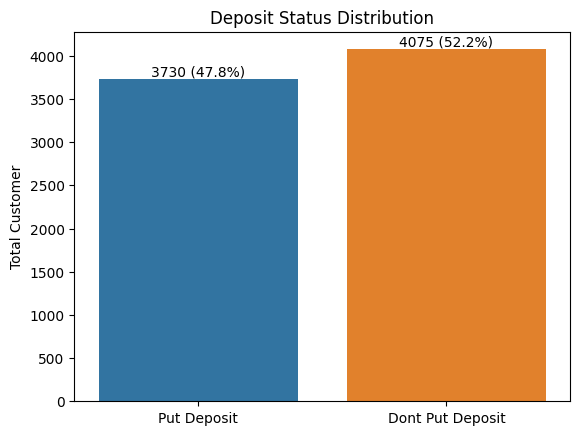

In [185]:
ax = sns.countplot(x=df["deposit"], hue=df["deposit"])

# tambahkan label count + percentage
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = count / total * 100

    ax.annotate(
        f'{count} ({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xlabel("")
plt.ylabel("Total Customer")
plt.title("Deposit Status Distribution")
plt.xticks(ticks=[0,1], labels=["Put Deposit", "Dont Put Deposit"])
plt.show()

Get Distribution of Feature (independent variabel) 
* Numeric : 'age', 'balance', 'pdays', 'campaign'
* Categoric : 'job', 'housing', 'loan', 'poutcome', 'month' ,'contact' 

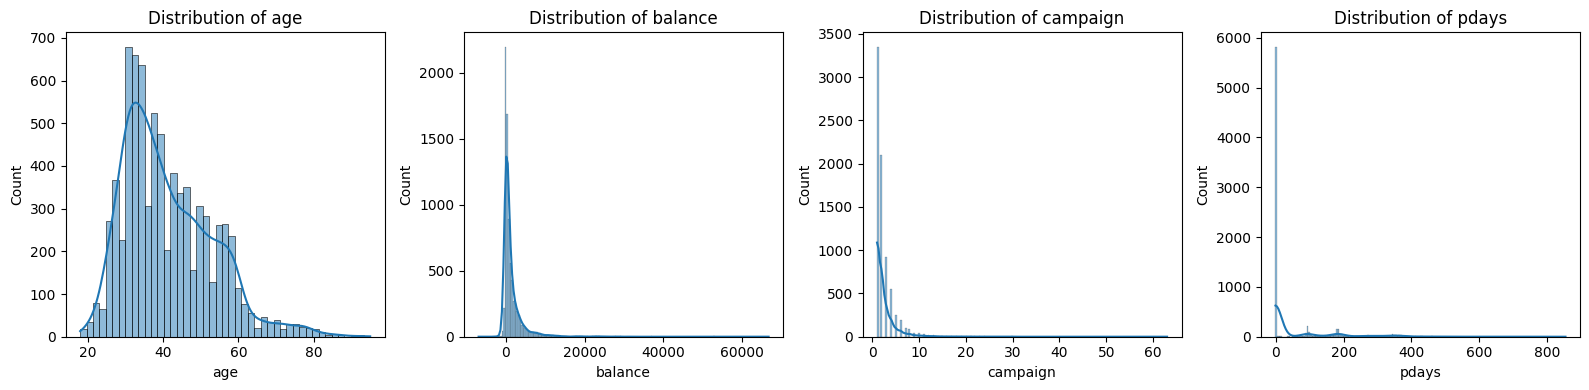

In [178]:
# Distribution of Numerical Features

num_var = ["age","balance", "campaign", "pdays"]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
axes = axes.flatten()  # supaya bisa di-loop

for i, col in enumerate(num_var):
    
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

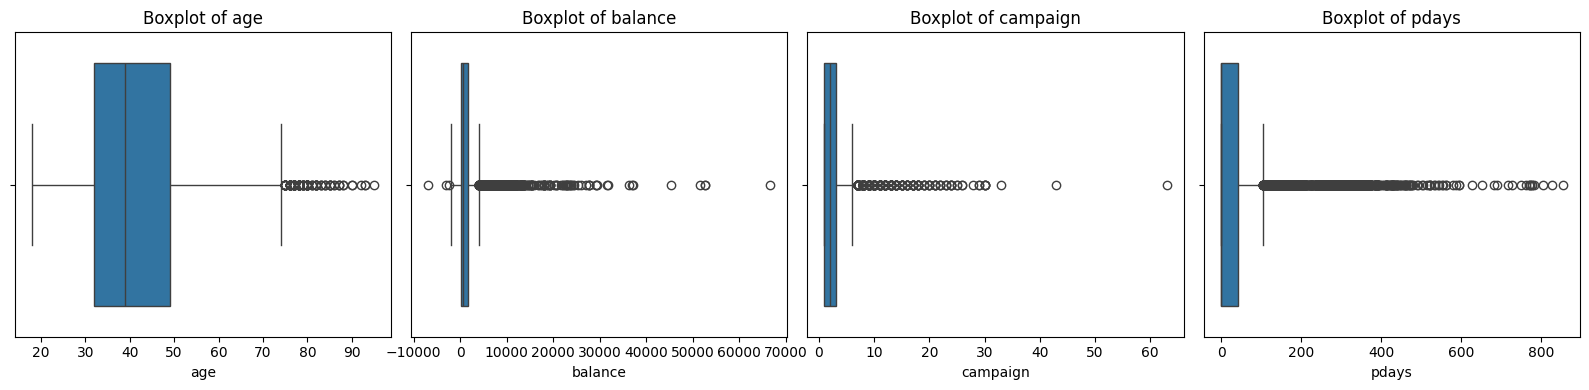

In [177]:
num_var = ["age","balance", "campaign", "pdays"]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
axes = axes.flatten()  # supaya bisa di-loop

for i, col in enumerate(num_var):
    
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

'job','housing', 'loan', 'contact', 'month', 'poutcome'

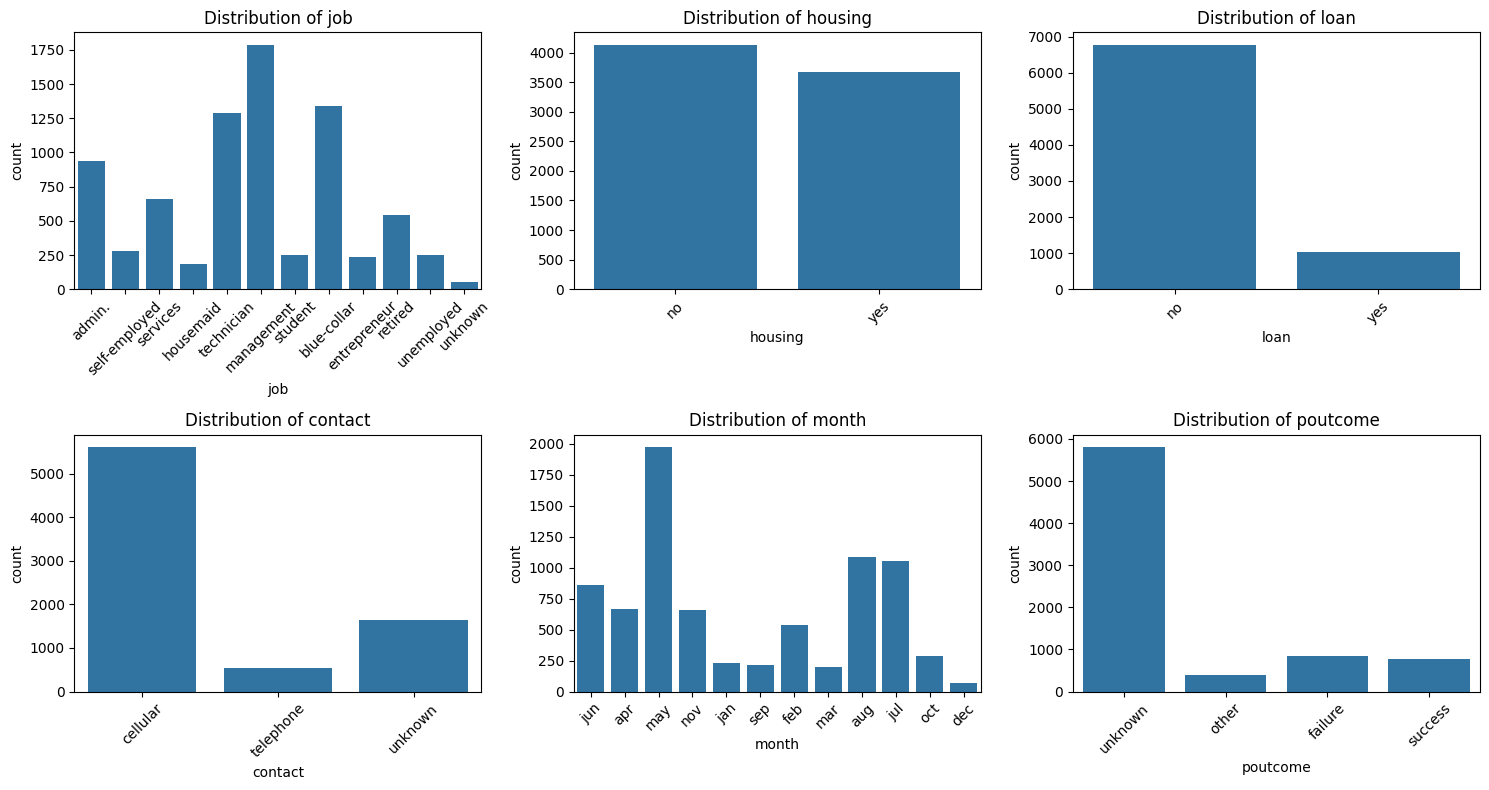

In [184]:
cat_var = ['job','housing','loan','contact','month','poutcome']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(cat_var):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Bivariate Analysis**

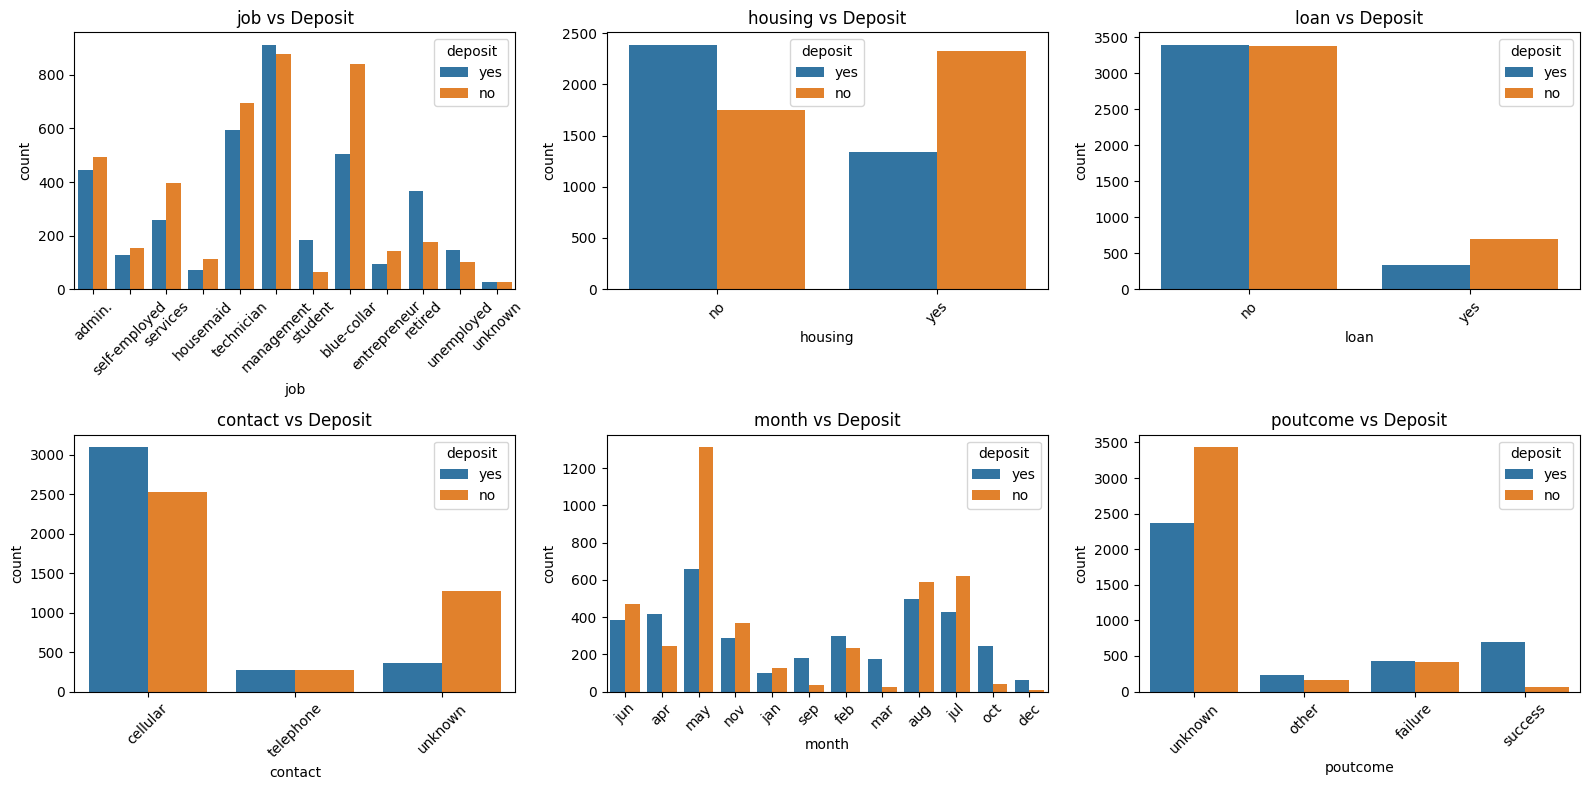

In [187]:
cat_var = ['job','housing','loan','contact','month','poutcome']

fig, axes = plt.subplots(2, 3, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(cat_var):
    sns.countplot(data=df, x=col, hue="deposit", ax=axes[i])
    axes[i].set_title(f'{col} vs Deposit')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

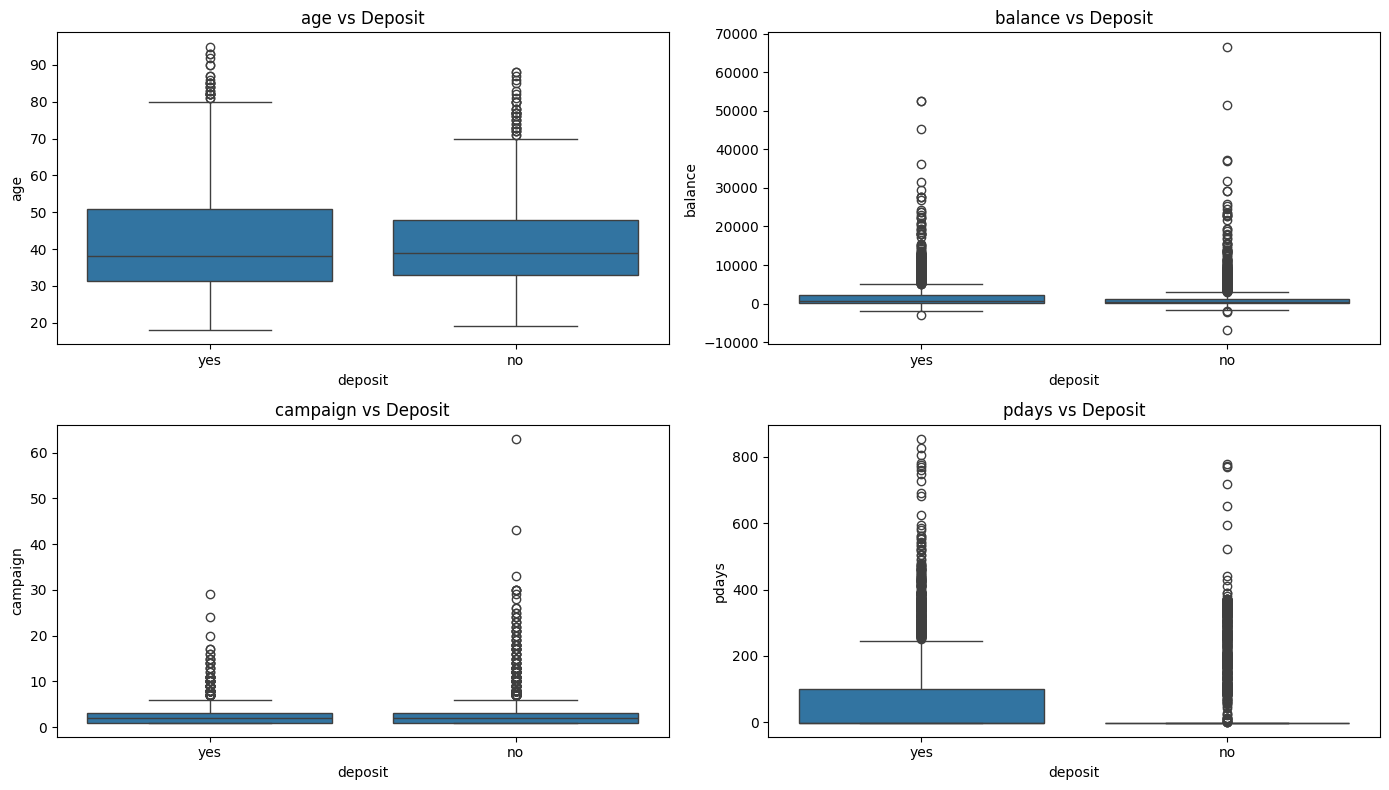

In [188]:
num_var = ["age","balance","campaign","pdays"]

fig, axes = plt.subplots(2, 2, figsize=(14,8))
axes = axes.flatten()

for i, col in enumerate(num_var):
    sns.boxplot(data=df, x="deposit", y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs Deposit')

plt.tight_layout()
plt.show()

**Multivariate Analysis**

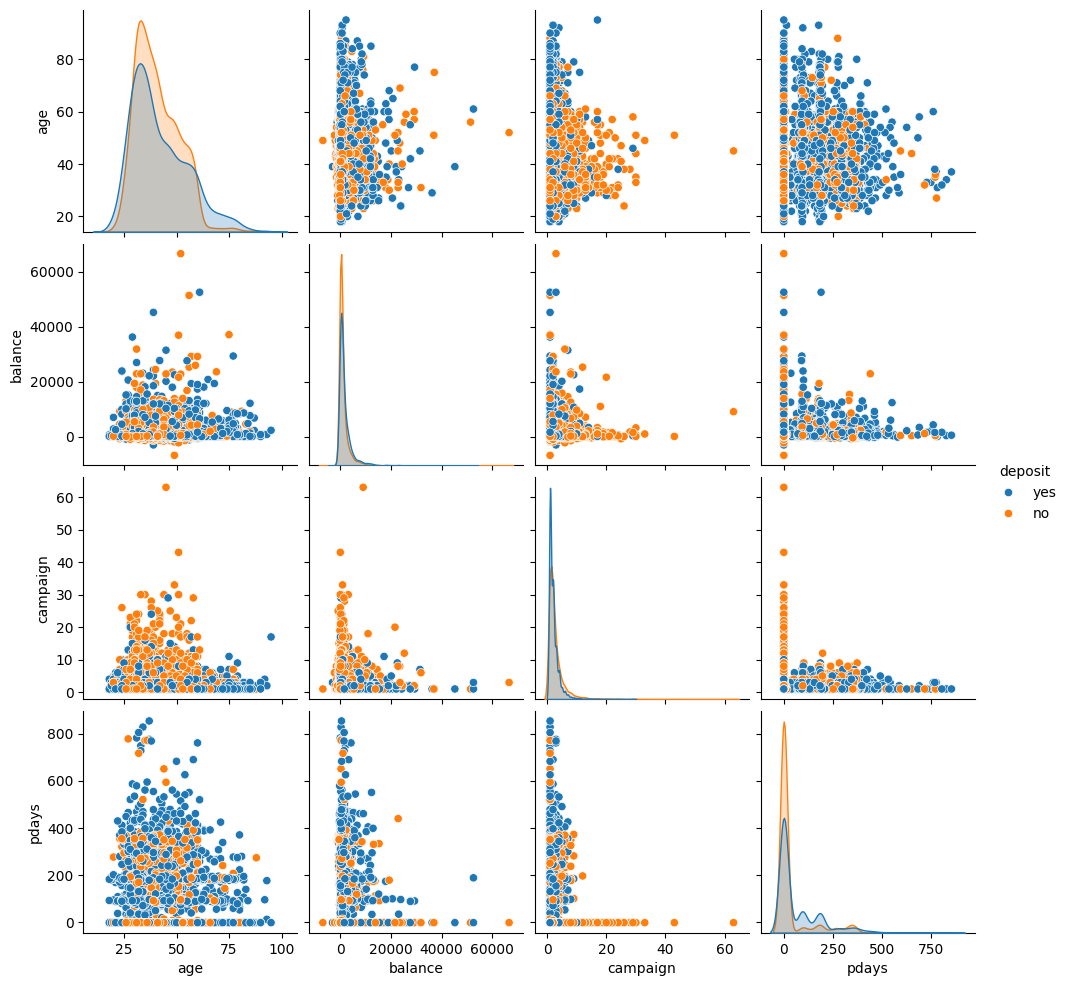

In [190]:
sns.pairplot(df[num_var + ["deposit"]], hue="deposit")
plt.show()

### 1.C Multicollinearity

In [74]:
X_numeric = df[["age","balance", "campaign", "pdays"]]

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

print(vif_data)

    feature       VIF
0       age  2.251682
1   balance  1.250739
2  campaign  1.748965
3     pdays  1.214343


Karena VIF < 4 maka tidak ada multicollinearity

## 2. Feature Engineering

### 2. A Data Preparation 

In [22]:
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


Sekarang mari kita melakukan fitur encoding untuk fitur2 categorical yang kita miliki.
Yang akan kita lakukan adalah :

1. Merubah fitur/kolom `age` tidak di encode/ menggunakan Robust Scaling.
2. Merubah fitur/kolom `job` menggunakan One Hot Encoding, karena fitur ini memiliki unique data yang tidak banyak dan tidak memiliki urutan/tidak ordinal.
3. Merubah fitur/kolom `balance`  tidak di encode/ dengan Robust Scaling.
4. Merubah fitur/kolom `housing` di ubah untuk yes = 1 dan no = 0.
5. Merubah fitur/kolom `loan` di ubah untuk yes = 1 dan no = 0
6. Merubah fitur/kolom `contact` menggunakan One Hot Encoding, karena fitur ini tidak memiliki urutan/tidak ordinal, dan juga jumlah unique datanya hanya sedikit.
7. Menghapus fitur/kolom `month` menggunakan One Hot Encoding, karena fitur ini tidak memiliki urutan/tidak ordinal, dan juga jumlah unique datanya hanya sedikit.
8. Merubah fitur/kolom `campaign` menggunakan One Hot Encoding, karena fitur ini tidak memiliki urutan/tidak ordinal, dan juga jumlah unique datanya hanya sedikit.
9. Merubah fitur/kolom `pdays` menggunakan Binary Encoding, karena fitur ini tidak memiliki urutan/tidak ordinal, dan juga jumlah unique datanya hanya sedikit. Menambahkan kolom pdays recency :"belum_pernah"
"sudah_lama"
"cukup_lama"
"belum_lama"
"baru" untuk nanti ordinal encoding
10. Merubah fitur/kolom `poutcome` menggunakan One Hot Encoding, karena fitur ini tidak memiliki urutan/tidak ordinal, dan juga jumlah unique datanya hanya sedikit.

11. Fitur/kolom `deposit`adalah label/ target.


In [ ]:
#df['housing'] = df['housing'].map({'yes':1,'no':0})
#df['loan']    = df['loan'].map({'yes':1,'no':0})

In [23]:
def pdays_recency(x):
    if x in [-1]:
        return "belum_pernah"
    elif x <= 30:
        return "baru"
    elif x <= 90:
        return "belum_lama"
    elif x <= 180:
        return "cukup_lama"
    else:
        return "sudah_lama"

df["pdays_recency"] = df["pdays"].apply(pdays_recency)

In [38]:
df["poutcome"].unique()

array(['unknown', 'other', 'failure', 'success'], dtype=object)

In [24]:
df["pdays_recency"].value_counts()

pdays_recency
belum_pernah    5809
sudah_lama      1099
cukup_lama       673
belum_lama       191
baru              33
Name: count, dtype: int64

In [25]:
recency_order = [
    "belum_pernah",
    "sudah_lama",
    "cukup_lama",
    "belum_lama",
    "baru"
]

In [26]:
pd.crosstab(df["pdays_recency"], df["deposit"], normalize="index")

deposit,no,yes
pdays_recency,,
baru,0.484848,0.515152
belum_lama,0.167539,0.832461
belum_pernah,0.591840,0.408160
cukup_lama,0.268945,0.731055
sudah_lama,0.371247,0.628753


In [27]:
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit,pdays_recency
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes,belum_pernah
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes,belum_pernah
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes,sudah_lama
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no,belum_pernah
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no,belum_pernah


### 2.B Preprocessing

In [45]:
y = df['deposit'].map({'no': 0, 'yes': 1})

In [46]:
# TODO
# Define feature and Target

# Variable Independent (Feature)
X = df.drop(columns=["deposit"])

# Variable Dependent (Target)
y = df["deposit"].map({'no': 0, 'yes': 1})

In [50]:
y

0       1
1       1
2       1
3       0
4       0
       ..
7808    1
7809    1
7810    0
7811    0
7812    1
Name: deposit, Length: 7805, dtype: int64

1. OneHotEncoding: housing, loan, contact, job, month, poutcome
2. RobustScaler: age, balance, campaign, pdays,
3. Ordinal: pdays_recency

In [47]:
numerical_feature = ['age','balance','campaign','pdays']
categorical_feature = ['housing', 'loan', 'contact', 'job', 'month', 'poutcome']
ordinal_feature= ['pdays_recency']

In [106]:
# Split dataset into training and testing set
 
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [108]:
# Reset Index
X_train.reset_index(drop= True, inplace= True)
X_test.reset_index(drop= True, inplace= True)
y_train.reset_index(drop= True, inplace= True)
y_test.reset_index(drop= True, inplace= True)

# Data Overview
print("Feature Training Set (shape): ", X_train.shape)
print("Feature Testing Set (shape): ", y_train.shape)
X_train.head()

Feature Training Set (shape):  (6244, 11)
Feature Testing Set (shape):  (6244,)


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,pdays_recency
0,21,student,216,no,no,cellular,aug,1,-1,unknown,belum_pernah
1,30,services,1599,no,no,cellular,feb,2,-1,unknown,belum_pernah
2,61,management,967,no,no,cellular,aug,1,-1,unknown,belum_pernah
3,30,self-employed,3137,yes,no,cellular,jul,7,-1,unknown,belum_pernah
4,35,technician,3160,yes,no,cellular,nov,2,95,failure,cukup_lama


In [52]:
y_train.value_counts()

deposit
0    3260
1    2984
Name: count, dtype: int64

data tidak imbalance

In [40]:
# Build Feature Engineering Pipeline

pipe_fe_numeric = Pipeline(steps=[
    ("feature_scaling", RobustScaler()) # step 2
])

pipe_fe_nominal = Pipeline(steps=[
    ("feature_encoding", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

pipe_fe_ordinal = Pipeline(steps=[
    ("feature_encoding", OrdinalEncoder(categories=[recency_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
))
])

In [41]:
# Build transformer for feature transformation
transformer = ColumnTransformer(transformers=[
    ("numerical_scaling", pipe_fe_numeric, numerical_feature),
    ("categorical_ohe", pipe_fe_nominal, categorical_feature),
    ("categorical_ordinal", pipe_fe_ordinal, ordinal_feature)
], verbose_feature_names_out=False, remainder="passthrough")

transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('categorical_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transform

### 2.C Modelling and Cross Validation

In [ ]:
logreg = LogisticRegression(random_state=0)
knn = KNeighborsClassifier()
tree = DecisionTreeClassifier(random_state=0) 
rf = RandomForestClassifier() 
xgb = XGBClassifier()
lgbm = lgb.LGBMClassifier()

In [53]:
list_model = [logreg, knn, tree, rf, xgb, lgbm]
list_all_score = []
list_mean_score = []
list_std = []

for model in list_model:
    # pipeline
    pipe_prep_model =  Pipeline([
        ('preprocessing', transformer),
        ('modeling', model)
    ])

    # cross val
    crossval = cross_val_score(estimator=pipe_prep_model,
                    X = X_train,
                    y = y_train,
                    cv = 5,
                    scoring = 'recall',
                    error_score='raise'
                    ) 
    
    # recall
    list_all_score.append(crossval.round(2))
    list_mean_score.append(crossval.mean())
    list_std.append(crossval.std())

[LightGBM] [Info] Number of positive: 2387, number of negative: 2608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 4995, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.477878 -> initscore=-0.088546
[LightGBM] [Info] Start training from score -0.088546
[LightGBM] [Info] Number of positive: 2387, number of negative: 2608
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002434 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 4995, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.477878 -> initscore=-0.088546
[LightGBM]

In [223]:
df_benchmark = pd.DataFrame()
df_benchmark['algo'] = list_model
df_benchmark['all_score'] = list_all_score
df_benchmark['mean_score'] = list_mean_score
df_benchmark['std_score'] = list_std

df_benchmark.sort_values("mean_score",ascending=False)

,algo,all_score,mean_score,std_score
3,"(DecisionTreeClassifier(max_features='sqrt', r...","[0.63, 0.66, 0.63, 0.65, 0.62]",0.637395,0.013752
4,"XGBClassifier(base_score=None, booster=None, c...","[0.65, 0.65, 0.61, 0.63, 0.6]",0.628008,0.020449
5,LGBMClassifier(),"[0.63, 0.65, 0.6, 0.64, 0.59]",0.620297,0.023454
2,DecisionTreeClassifier(random_state=0),"[0.63, 0.61, 0.6, 0.61, 0.61]",0.614276,0.010614
1,KNeighborsClassifier(),"[0.64, 0.65, 0.58, 0.59, 0.61]",0.614276,0.025154
0,LogisticRegression(random_state=0),"[0.6, 0.61, 0.57, 0.62, 0.57]",0.591480,0.020133


Untuk kasus campaign bank marketing (deposit):

Tujuan = maksimalkan recall (minimalkan false negative)

Model terbaik saat ini (rata-rata performa di data training): 
* Random Forest : 0.637
* XGBoost : 0.628
* LGBM : 0.6202

### 2.D Model Benchmarking : Test Data

In [231]:
def y_pred_func(model):
    pipe = Pipeline([
        ('preprocess', transformer),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    return pipe, y_pred


for model, name in zip(models, 
                      ['Logistic Regression', 'KNN', 'Decision Tree',
                       'Random Forest', 'XGBoost','LightGBM']):
    
    pipe, y_pred = y_pred_func(model)
    
    y_predict_proba = pipe.predict_proba(X_test)[:,1]
    
    score_roc_auc.append(roc_auc_score(y_test,y_predict_proba))
    
    print(name,'\n', classification_report(y_test,y_pred))

Logistic Regression 
               precision    recall  f1-score   support

           0       0.70      0.83      0.76       835
           1       0.75      0.58      0.66       726

    accuracy                           0.72      1561
   macro avg       0.72      0.71      0.71      1561
weighted avg       0.72      0.72      0.71      1561

KNN 
               precision    recall  f1-score   support

           0       0.69      0.73      0.71       835
           1       0.67      0.63      0.65       726

    accuracy                           0.68      1561
   macro avg       0.68      0.68      0.68      1561
weighted avg       0.68      0.68      0.68      1561

Decision Tree 
               precision    recall  f1-score   support

           0       0.65      0.64      0.65       835
           1       0.59      0.60      0.60       726

    accuracy                           0.62      1561
   macro avg       0.62      0.62      0.62      1561
weighted avg       0.62      0

In [232]:
results = []

for model, name in zip(models,
                      ['Logistic Regression', 'KNN', 'Decision Tree',
                       'Random Forest', 'XGBoost','LightGBM']):
    
    pipe = Pipeline([
        ('preprocessing', transformer),
        ('modeling', model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_proba = pipe.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'model': name,
        'roc_auc_score': auc
    })

results_df = pd.DataFrame(results).sort_values(
    by='roc_auc_score', ascending=False
)

results_df

[LightGBM] [Info] Number of positive: 3004, number of negative: 3240
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 6244, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481102 -> initscore=-0.075629
[LightGBM] [Info] Start training from score -0.075629


,model,roc_auc_score
5,LightGBM,0.790287
4,XGBoost,0.780112
0,Logistic Regression,0.773856
3,Random Forest,0.764896
1,KNN,0.723457
2,Decision Tree,0.622701


Pemilihan model terbaik:
**LightGBM paling stabil**
* Accuracy tertinggi (0.74)
* Precision tertinggi (0.78)
* F1 tertinggi (0.69)
* Recall hanya beda 0.01 dari RF (0.62)

Namun akan dilakukan tuning pada 3 Model yaitu:

* RF
* XGBoost
* LGBM


### 2.E Hyperparameter Tuning Model RF

In [55]:
pipe_prep_model

,steps,"[('preprocessing', ...), ('modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('categorical_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must 

In [56]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [110]:
pipe_prep_model =  Pipeline([
        ('preprocessing', transformer),
        ('modeling', rf)
    ])

# hyperparam
hyperparam = {
    'modeling__n_estimators': [100, 200, 300, 500],
    'modeling__max_depth': [None, 5, 10, 20],
    'modeling__min_samples_split': [2, 5, 10],
    'modeling__min_samples_leaf': [1, 2, 5],
    'modeling__max_features': ['sqrt', 'log2'],
    'modeling__class_weight': [None, 'balanced']
}

rsearch1 = RandomizedSearchCV(
    estimator=pipe_prep_model,
    param_distributions=hyperparam,
    cv = 5,
    n_jobs=-1,
    scoring='recall',
    n_iter=50,
    random_state=42
)

In [111]:
rsearch1.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modeling__class_weight': [None, 'balanced'], 'modeling__max_depth': [None, 5, ...], 'modeling__max_features': ['sqrt', 'log2'], 'modeling__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross

In [ ]:
rsearch1.best_estimator_

,steps,"[('preprocessing', ...), ('modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('categorical_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must 

In [ ]:
rsearch1.best_score_

np.float64(0.6404112284015155)

In [112]:
pd.DataFrame(rsearch1.cv_results_).head(5).sort_values("mean_test_score",ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_modeling__n_estimators,param_modeling__min_samples_split,param_modeling__min_samples_leaf,param_modeling__max_features,param_modeling__max_depth,param_modeling__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,10.867979,0.892813,0.221436,0.009392,300,10,2,log2,None,balanced,"{'modeling__n_estimators': 300, 'modeling__min...",0.618968,0.602329,0.692180,0.653910,0.645000,0.642478,0.030893,6
0,12.227570,1.657844,0.315885,0.071384,300,5,2,sqrt,20,None,"{'modeling__n_estimators': 300, 'modeling__min...",0.607321,0.585691,0.667221,0.637271,0.630000,0.625501,0.027622,21
3,4.516345,0.089553,0.180649,0.007122,300,5,5,log2,10,balanced,"{'modeling__n_estimators': 300, 'modeling__min...",0.607321,0.587354,0.647255,0.628952,0.633333,0.620843,0.021089,24
4,2.369767,0.117160,0.158628,0.006288,300,5,1,log2,5,balanced,"{'modeling__n_estimators': 300, 'modeling__min...",0.590682,0.555740,0.618968,0.630616,0.583333,0.595868,0.026590,38
1,4.880788,1.802932,0.275904,0.144315,300,10,1,log2,5,None,"{'modeling__n_estimators': 300, 'modeling__min...",0.539101,0.522463,0.544093,0.545757,0.520000,0.534283,0.010907,49


In [64]:
y_test.value_counts()

deposit
0    815
1    746
Name: count, dtype: int64

#### 2.D.1 Predict to Set

**Before Tuning**

In [65]:
# define model
model = rf

# pipe transformer & modeling
pipe_prep_model = Pipeline([
    ('preprocessing', transformer),
    ('model', rf)
])

# fit
pipe_prep_model.fit(X_train, y_train)

# predict
y_pred_before = pipe_prep_model.predict(X_test)
y_pred_before

# recall
recall_score(y_test, y_pred_before)

0.646112600536193

**After Tuning**

In [ ]:
rsearch1.best_estimator_

In [ ]:
# define model
model_tuning = rsearch1.best_estimator_

# fit
model_tuning.fit(X_train, y_train)

# predict
y_pred_after = model_tuning.predict(X_test)

# recall
recall_score(y_test, y_pred_after)

0.6420911528150134

### 2.F Hyperparameter Tuning Model XGB

In [80]:
XGBClassifier(XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
))

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.","XGBClassifier...ree=None, ...)"
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegre

In [151]:
pipe_prep_model_xgb =  Pipeline([
        ('preprocessing', transformer),
        ('modeling', xgb)
    ])

# hyperparam
hyperparam_xgb = {
    'modeling__n_estimators': [100, 200, 300, 400],
    'modeling__max_depth': [3, 5, 7, 9],
    'modeling__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'modeling__min_child_weight': [1, 3, 5],
    'modeling__subsample': [0.7, 0.8, 0.9],
    'modeling__colsample_bytree': [0.7, 0.8, 0.9],
    'modeling__gamma': [0, 1, 3],
    'modeling__reg_alpha': [0, 0.1, 1],
    'modeling__reg_lambda': [1, 5, 10]
}

rsearch_xgb = RandomizedSearchCV(
    estimator=pipe_prep_model_xgb,
    param_distributions=hyperparam_xgb,
    cv = 5,
    n_jobs=-1,
    scoring='recall',
    n_iter=50,
    random_state=42
)

In [152]:
rsearch_xgb.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modeling__colsample_bytree': [0.7, 0.8, ...], 'modeling__gamma': [0, 1, ...], 'modeling__learning_rate': [0.01, 0.05, ...], 'modeling__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validati

In [ ]:
rsearch_xgb.best_estimator_

,steps,"[('preprocessing', ...), ('modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('categorical_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must 

In [ ]:
rsearch_xgb.best_score_

np.float64(0.6266657673153239)

**Before Tuning=XGB** 

In [153]:
# define model
model = xgb

# pipe transformer & modeling
pipe_prep_model_xgb = Pipeline([
    ('preprocessing', transformer),
    ('model', xgb)
])

# fit
pipe_prep_model_xgb.fit(X_train, y_train)

# predict
y_pred_before_xgb = pipe_prep_model_xgb.predict(X_test)
y_pred_before_xgb

# recall
recall_score(y_test, y_pred_before_xgb)

0.628099173553719

**After Tuning=XGB** 

In [155]:
# define model
model_tuning_xgb = rsearch_xgb.best_estimator_

# fit
model_tuning_xgb.fit(X_train, y_train)

# predict
y_pred_after_xgb = model_tuning_xgb.predict(X_test)

# recall
recall_score(y_test, y_pred_after_xgb)

0.6584022038567493

### 2.G Hyperparameter Tuning Model LGBM

In [135]:
lgb.LGBMClassifier()

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [156]:
pipe_prep_model_lgbm =  Pipeline([
        ('preprocessing', transformer),
        ('modeling', lgbm)
    ])

# hyperparam
hyperparam_lgbm = {
    'modeling__n_estimators': [300, 500, 800],
    'modeling__learning_rate': [0.01, 0.05, 0.1],
    'modeling__max_depth': [-1,10, 20],
    'modeling__num_leaves': [31, 50, 70],
    'modeling__min_child_samples': [20, 30, 50],
    'modeling__subsample': [0.6, 0.8, 1.0],
    'modeling__colsample_bytree': [0.6, 0.8, 1.0],
    'modeling__class_weight': [None, 'balanced']
}

rsearch_lgbm = RandomizedSearchCV(
    estimator=pipe_prep_model_lgbm,
    param_distributions=hyperparam_lgbm,
    cv=5,
    n_jobs=-1,
    scoring='recall',
    n_iter=50,
    random_state=42
)

In [157]:
rsearch_lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 3004, number of negative: 3240
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 6244, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modeling__class_weight': [None, 'balanced'], 'modeling__colsample_bytree': [0.6, 0.8, ...], 'modeling__learning_rate': [0.01, 0.05, ...], 'modeling__max_depth': [-1, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the various

In [158]:
rsearch_lgbm.best_estimator_

,steps,"[('preprocessing', ...), ('modeling', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_scaling', ...), ('categorical_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must 

In [159]:
rsearch_lgbm.best_score_

np.float64(0.6611170271769273)

2.F.1 Predict to Set

Before Tuning LGBM

In [160]:
# define model
model = lgbm

# pipe transformer & modeling
pipe_prep_model_lgbm = Pipeline([
    ('preprocessing', transformer),
    ('model', lgbm)
])

# fit
pipe_prep_model_lgbm.fit(X_train, y_train)

# predict
y_pred_before_lgbm = pipe_prep_model_lgbm.predict(X_test)
y_pred_before_lgbm

# recall
recall_score(y_test, y_pred_before_lgbm)

[LightGBM] [Info] Number of positive: 3004, number of negative: 3240
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 6244, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481102 -> initscore=-0.075629
[LightGBM] [Info] Start training from score -0.075629


0.6184573002754821

After Tuning LGBM

In [161]:
# define model
model_tuning_lgbm = rsearch_lgbm.best_estimator_

# fit
model_tuning_lgbm.fit(X_train, y_train)

# predict
y_pred_after_lgbm = model_tuning_lgbm.predict(X_test)

# recall
recall_score(y_test, y_pred_after_lgbm)

[LightGBM] [Info] Number of positive: 3004, number of negative: 3240
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 6244, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

0.6556473829201102

In [233]:
y_pred_default = pipe_prep_model_lgbm.predict(X_test)
y_pred_proba_default = pipe_prep_model_lgbm.predict_proba(X_test)[:,1]
y_pred_tuned = model_tuning_lgbm.predict(X_test)
y_pred_proba_tuned = model_tuning_lgbm.predict_proba(X_test)[:,1]

threshold = 0.30
y_pred_030 = (y_proba >= threshold).astype(int)

print("Classification Report (Threshold 0.50)")
print(classification_report(y_test, y_pred_tuned))


Classification Report (Threshold 0.50)
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       835
           1       0.72      0.66      0.69       726

    accuracy                           0.72      1561
   macro avg       0.72      0.72      0.72      1561
weighted avg       0.72      0.72      0.72      1561



Cek Threshold 0.3

In [196]:
y_pred_default = pipe_prep_model_lgbm.predict(X_test)
y_pred_proba_default = pipe_prep_model_lgbm.predict_proba(X_test)[:,1]
y_pred_tuned = model_tuning_lgbm.predict(X_test)
y_pred_proba_tuned = model_tuning_lgbm.predict_proba(X_test)[:,1]

threshold = 0.30
y_pred_030 = (y_proba >= threshold).astype(int)

print("Classification Report (Threshold 0.30)")
print(classification_report(y_test, y_pred_030))


Classification Report (Threshold 0.30)
              precision    recall  f1-score   support

           0       0.80      0.49      0.61       835
           1       0.59      0.86      0.70       726

    accuracy                           0.66      1561
   macro avg       0.70      0.67      0.65      1561
weighted avg       0.70      0.66      0.65      1561



In [193]:
thresholds = np.arange(0.05, 0.6, 0.05)

for t in thresholds:
    y_pred_temp = (y_proba >= t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred_temp))


Threshold 0.05
              precision    recall  f1-score   support

           0       0.88      0.01      0.02       835
           1       0.47      1.00      0.64       726

    accuracy                           0.47      1561
   macro avg       0.67      0.50      0.33      1561
weighted avg       0.69      0.47      0.30      1561


Threshold 0.1
              precision    recall  f1-score   support

           0       0.85      0.03      0.05       835
           1       0.47      0.99      0.64       726

    accuracy                           0.48      1561
   macro avg       0.66      0.51      0.35      1561
weighted avg       0.67      0.48      0.33      1561


Threshold 0.15000000000000002
              precision    recall  f1-score   support

           0       0.85      0.11      0.20       835
           1       0.49      0.98      0.65       726

    accuracy                           0.51      1561
   macro avg       0.67      0.54      0.42      1561
weighted avg

In [ ]:
roc_auc_default = roc_auc_score(y_test, y_pred_proba_default)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print('ROC AUC Score Default LGBM : ', roc_auc_default)
print('ROC AUC Score Tuned LGBM : ', roc_auc_tuned)

ROC AUC Score Default LGBM :  0.790287194206628
ROC AUC Score Tuned LGBM :  0.7754416786262186


In [216]:
report_default = classification_report(y_test, y_pred_default)
report_tuned = classification_report(y_test, y_pred_tuned)
report_030 = classification_report(y_test, y_pred_030)

print('Classification Report Tuned LGBM : \n', report_tuned)
print('Classification Report Tuned Threshold 0.3 LGBM : \n', report_030)

Classification Report Tuned LGBM : 
               precision    recall  f1-score   support

           0       0.72      0.78      0.75       835
           1       0.72      0.66      0.69       726

    accuracy                           0.72      1561
   macro avg       0.72      0.72      0.72      1561
weighted avg       0.72      0.72      0.72      1561

Classification Report Tuned Threshold 0.3 LGBM : 
               precision    recall  f1-score   support

           0       0.80      0.49      0.61       835
           1       0.59      0.86      0.70       726

    accuracy                           0.66      1561
   macro avg       0.70      0.67      0.65      1561
weighted avg       0.70      0.66      0.65      1561



### 2.H Feature Importances

Fitur/kolom apa saja yang paling penting untuk model LGBM.

In [146]:
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(15)

,feature,importance
1,balance,0.159198
0,age,0.144044
7,contact_unknown,0.075262
2,campaign,0.071426
3,pdays,0.070322
31,poutcome_success,0.069256
4,housing_yes,0.050277
33,pdays_recency,0.028588
32,poutcome_unknown,0.025331
5,loan_yes,0.023787


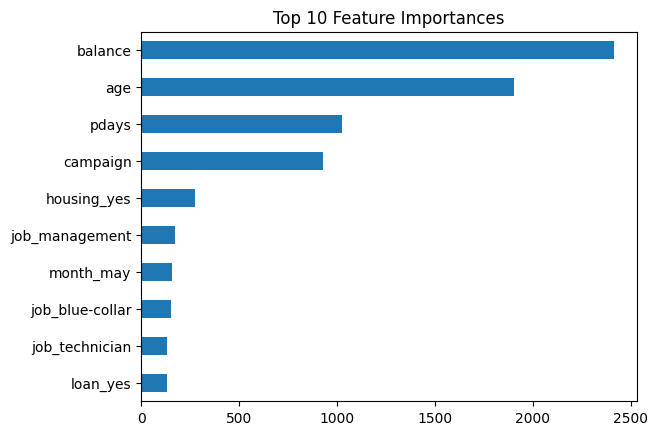

In [224]:
# ambil nama fitur setelah preprocessing
feature_names = model_tuning_lgbm.named_steps['preprocessing'].get_feature_names_out()

# ambil feature importance dari RF
importances =model_tuning_lgbm.named_steps['modeling'].feature_importances_

# buat Series dan urutkan
coef1 = pd.Series(importances, index=feature_names) \
            .sort_values(ascending=False) \
            .head(10)

# plot
coef1.plot(kind='barh', title='Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

Terlihat bahwa ternyata untuk model LGBM kita, fitur/kolom balance adalah yang paling penting, kemudian diikuti dengan age, contact, campaign, pdays, dan selanjutnya.

### 2. I. Confusion Matrix

In [148]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [210]:
# conf. before tuning threshold 0.5
cm_before = confusion_matrix(y_test, y_pred_before_lgbm)

In [207]:
# conf. after tuning threshold 0.5
cm_after = confusion_matrix(y_test, y_pred_after_lgbm)

In [201]:
# conf. after tuning threshold 0.3
y_proba = pipe.predict_proba(X_test)[:,1]
y_pred_03 = (y_proba >= 0.3).astype(int)
cm_03 = confusion_matrix(y_test, y_pred_03)

In [208]:
cm_after, cm_03

(array([[653, 182],
        [250, 476]]),
 array([[411, 424],
        [105, 621]]))

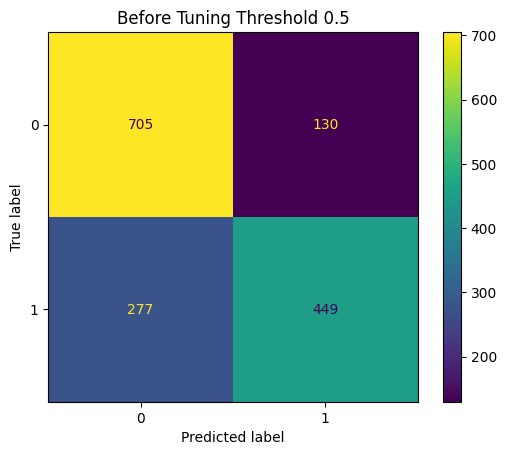

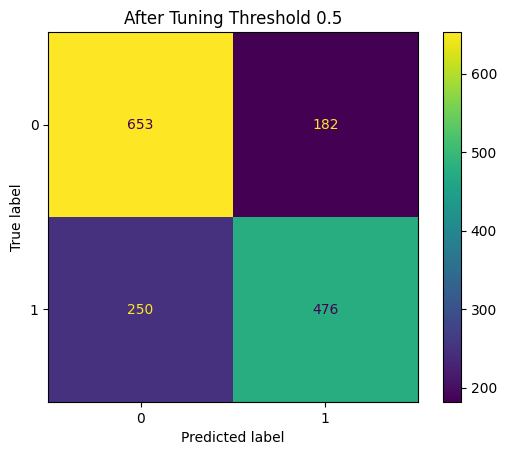

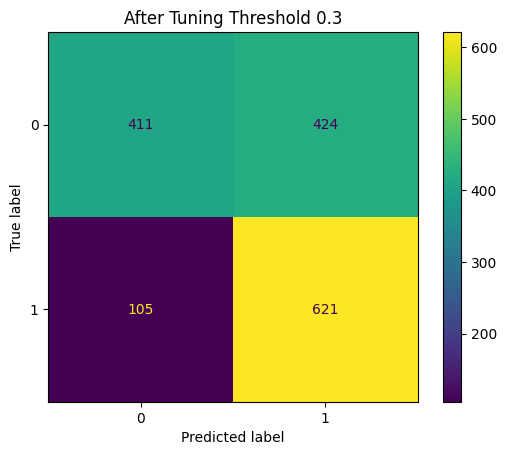

In [213]:
# # after tuning threshold 0.5
# plt.figure(figsize=(5,5))

# plt.subplot(3,1,1)
disp_before = ConfusionMatrixDisplay(confusion_matrix=cm_before)
disp_before.plot()
plt.title('Before Tuning Threshold 0.5')

# plt.subplot(3,1,2)
disp_before = ConfusionMatrixDisplay(confusion_matrix=cm_after)
disp_before.plot()
plt.title('After Tuning Threshold 0.5')

# after tuning threshold 0.3
# plt.subplot(3,1,3)
disp_after = ConfusionMatrixDisplay(confusion_matrix=cm_03)
disp_after.plot()
plt.title('After Tuning Threshold 0.3')

plt.show()


**1. Biaya Campaign per Nasabah** (perkiraan)

Jenis Campaign	Estimasi Biaya per Nasabah
* Telemarketing call	Rp20.000 – Rp50.000
* SMS blast	Rp2.000 – Rp10.000
* Email campaign	Rp5.000 – Rp15.000
* Sales call / field sales	Rp50.000 – Rp150.000
* Multichannel (gabungan)	Rp70.000 – Rp250.000

Medium campaign digital + call center biasanya di kisaran Rp40.000 – Rp120.000 per target nasabah

**2. Potensi Kerugian Jika Satu Nasabah Potensial Hilang**

Untuk menghitung kerugian kehilangan satu calon nasabah yang seharusnya jadi deposito, kita estimasi berdasarkan:

- Rata-rata nilai deposito
- Margin bunga / spread bank
- Lama simpanan deposito

Contoh Perhitungan Sederhana

Misalnya:

* Nilai deposito per nasabah: Rp50.000.000
* Margin bunga bank per tahun: 2%
* Lama simpanan: 6 bulan
* Maka potensi pendapatan bunga bersih: = Rp50.000.000 × 2% × 0.5 = Rp500.000

Jadi, jika satu calon yang seharusnya jadi nasabah tidak jadi, bank kehilangan potensi pendapatan bunga ± Rp500.000

Kesimpulan:
- Berdasarkan hasil modeling yang telah dilakukan didapatkan bahwa cost/ kerugian perusahaan sebesar:

1. Setelah Tuning Threshold 0.5
- FP = 182 x 100.000 = 18.200.000
- FN = 250 x 500.000 =  125.000.000
- Total = 143.200.000
 
2. Setelah Tuning Threshold 0.3
- FP = 424 x 100.000 = 42.400.000 
- FN = 105 x 500.000 = 52.500.000
- Total = 94.900.000

Modeling after tuning dapat mengurangi cost perusahaan

## 3. Conclusion & Recommendation

In [218]:
print('Classification Report Tuned and Threshold 0.3 LGBM : \n', report_030)

Classification Report Tuned and Threshold 0.3 LGBM : 
               precision    recall  f1-score   support

           0       0.80      0.49      0.61       835
           1       0.59      0.86      0.70       726

    accuracy                           0.66      1561
   macro avg       0.70      0.67      0.65      1561
weighted avg       0.70      0.66      0.65      1561



Berdasarkan hasil classification report dari model kita, kita dapat menyimpulkan/mengambil konklusi bahwa :

* 49% tidak tertarik (tidak ditawarkan)- 51% diprediksi tertarik >> tidak tertarik (ditawarkan)
* 86% tertarik (ditawarkan) - 14% diprediksi tidak tertarik >> tertarik  (tidak ditawarkan)

Model kita ini memiliki ketepatan prediksi kandidat yang tertarik sebesar 59% (precisionnya), jadi setiap model kita memprediksi bahwa seorang kandidat itu tertarik, maka kemungkinan tebakannya benar itu sebesar 59% kurang lebih.

Support:

Class 1 (Tertarik) = 726

Class 0 (Tidak tertarik) = 835

Recall class 1 = 0.86

Precision class 1 = 0.59

Recall class 0 = 0.49

Hitung Angka Nyata

**Untuk class 1 (yang tertarik):**

Recall 86% →
TP = 0.86 × 726 ≈ 624
FN = 726 − 624 = 102

**Untuk class 0:**

Recall 49% →
TN = 0.49 × 835 ≈ 409
FP = 835 − 409 = 426

**Tanpa Model**

Total orang = 1561
Biaya per orang = Rp100.000

Total biaya =
1561 × 100.000 = Rp156.100.000

Semua yang tertarik didapat = 726 orang

**Dengan Model**

Yang ditawarkan hanya Predicted 1:

Predicted 1 = TP + FP
= 624 + 426
= 1050 orang

Biaya campaign:

1050 × 100.000
= Rp105.000.000

**Revenue yang Didapat**

Asumsi 1 depositor menghasilkan Rp500.000

TP = 624 orang

Revenue =
624 × 500.000
= Rp312.000.000

Net Profit

312.000.000 − 105.000.000
= Rp207.000.000


**Loss karena FN**

FN = 102 orang
Potensi revenue hilang:
102 × 500.000
= Rp 51.000.000

**TANPA MODEL**

Biaya = 156.100.000
Revenue = 726 × 500.000 = 363.000.000

Net Profit =
363.000.000 − 156.100.000
= 206.900.000

**DENGAN MODEL**

Biaya = 105.000.000
Revenue = 312.000.000

Net Profit =
312.000.000 − 105.000.000
= 207.000.000

**Dalam simulasi ini:**

Model 0.3 lebih untung sedikit:
207 juta > 206.9 juta

Artinya:
**Secara potensi maksimal: Tanpa model lebih aman karena tidak kehilangan 102 calon deposito**

#### Recommendation

Untuk Strategi Bank Campaign:
* Biaya campaign untuk satu orang (Rp 100 rb) jauh lebih kecil daripada potensi revenue yang hilang (~Rp500 rb. Artinya FN 5x lebih mahal daripada FP.
* Kalau bank punya: Kapasitas call center besar, Budget cukup, Tidak masalah menghubungi banyak orang, maka Lebih aman TANPA model.
* Kalau bank tidak punya: Kapasitas call center, Budget, bermasalah menghubungi banyak orang, maka Lebih baik MENGGUNAKAN model.
* Berdasarkan analisis cost-benefit, penggunaan model dengan threshold 0.3 memberikan efisiensi biaya campaign dan profit yang sedikit lebih tinggi dibandingkan tanpa model. Namun, selisih profit relatif kecil karena cost ratio campaign terhadap revenue cukup rendah. Oleh karena itu, keputusan implementasi model perlu mempertimbangkan kapasitas operasional dan strategi pemasaran bank.

# Thank You